In [ ]:
# CELL 1 — Remove torchao completely, it is not needed for LoRA training

!pip uninstall -y torchao -q

!pip install -q \
    "peft>=0.14.0" \
    "diffusers>=0.31.0" \
    "accelerate>=1.0.0" \
    "transformers>=4.46.0" \
    "datasets>=2.20.0" \
    "bitsandbytes>=0.43.0" \
    "safetensors>=0.4.0"

# Confirm torchao is gone
try:
    import torchao
    print(f"WARNING: torchao still present: {torchao.__version__}")
except ImportError:
    print("OK: torchao removed successfully")

import peft, diffusers, accelerate, transformers
print(f"peft:         {peft.__version__}")
print(f"diffusers:    {diffusers.__version__}")
print(f"accelerate:   {accelerate.__version__}")
print(f"transformers: {transformers.__version__}")
print("\nAll good — Runtime > Restart Session now")

import os
os.kill(os.getpid(), 9)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
from huggingface_hub import notebook_login
notebook_login()

README.md:   0%|          | 0.00/313 [00:00<?, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/324M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/328M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2202 [00:00<?, ? examples/s]

Total dataset size: 2202 examples


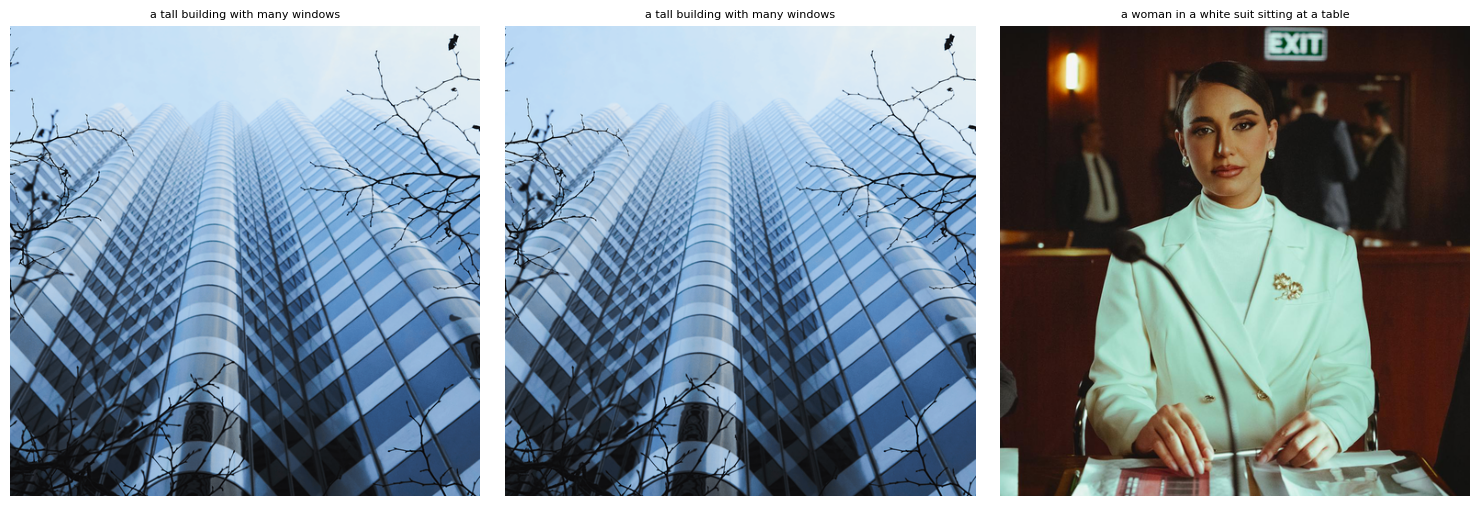

In [3]:
from datasets import load_dataset
import matplotlib.pyplot as plt
from PIL import Image

dataset_name = "Dhruvi512/office-workspace-dataset"
dataset = load_dataset(dataset_name)

# Access the 'train' split, assuming it's available
# You might need to adjust this if your dataset has a different split name (e.g., 'data')
if 'train' in dataset:
    data_split = dataset['train']
elif 'data' in dataset:
    data_split = dataset['data']
else:
    # Fallback to the first available split if names are unexpected
    first_split_name = list(dataset.keys())[0]
    data_split = dataset[first_split_name]
    print(f"Warning: 'train' or 'data' split not found. Using '{first_split_name}' split.")


print(f"Total dataset size: {len(data_split)} examples")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i in range(min(3, len(data_split))):
    example = data_split[i]
    image = example['image']
    caption = example['text']

    # Ensure image is a PIL Image object
    if not isinstance(image, Image.Image):
        image = Image.open(image) # Assuming image column contains paths if not direct PIL images

    axes[i].imshow(image)
    axes[i].set_title(caption, fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [4]:
import subprocess
subprocess.run(["pip", "uninstall", "-y", "torchao"], capture_output=True)
print("torchao removed")

import torch
import torch.nn.functional as F
from accelerate import Accelerator
from accelerate.utils import set_seed
from diffusers import AutoencoderKL, DDPMScheduler, UNet2DConditionModel
from diffusers.optimization import get_scheduler
from transformers import AutoTokenizer, CLIPTextModel
from peft import LoraConfig, get_peft_model
from datasets import load_dataset
from torchvision import transforms
from tqdm.auto import tqdm
import os, gc, torch

# ─── CONFIG (safe for T4 free tier) ───────────────────────────────────────────
MODEL_ID        = "runwayml/stable-diffusion-v1-5"
DATASET_NAME    = "Dhruvi512/office-workspace-dataset"
OUTPUT_DIR      = "/content/officeworkspace-lora/"

LORA_RANK       = 4
LORA_ALPHA      = 16        # FIX: was 32 — lower alpha = more stable training
TARGET_MODULES  = ["to_q", "to_v"]  # FIX: only 2 modules, saves ~30% VRAM vs 4

TRAIN_STEPS     = 1000      # Good quality without crashing
LEARNING_RATE   = 1e-4
BATCH_SIZE      = 1
IMAGE_SIZE      = 256       # FIX: was 384 — 256 is safe on T4, still good quality
MIXED_PRECISION = "fp16"
GRADIENT_ACCUMULATION_STEPS = 2   # effective batch = 2, stable gradients

# ─── SETUP ────────────────────────────────────────────────────────────────────
set_seed(42)
gc.collect()
torch.cuda.empty_cache()

accelerator = Accelerator(
    mixed_precision=MIXED_PRECISION,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
)
weight_dtype = torch.float16

# ─── LOAD MODELS (directly in fp16 to save VRAM) ──────────────────────────────
# FIX: load everything in fp16 from the start instead of float32 then casting
noise_scheduler = DDPMScheduler.from_pretrained(MODEL_ID, subfolder="scheduler")
tokenizer       = AutoTokenizer.from_pretrained(MODEL_ID, subfolder="tokenizer", use_fast=False)
text_encoder    = CLIPTextModel.from_pretrained(MODEL_ID, subfolder="text_encoder", torch_dtype=weight_dtype)
vae             = AutoencoderKL.from_pretrained(MODEL_ID, subfolder="vae", torch_dtype=weight_dtype)
unet            = UNet2DConditionModel.from_pretrained(MODEL_ID, subfolder="unet", torch_dtype=weight_dtype)

vae.requires_grad_(False)
text_encoder.requires_grad_(False)

# Memory optimizations
unet.enable_gradient_checkpointing()
try:
    unet.enable_xformers_memory_efficient_attention()
    print("xformers enabled")
except Exception:
    print("xformers not available, using default attention")

# ─── APPLY LORA ───────────────────────────────────────────────────────────────
lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    init_lora_weights="gaussian",
    target_modules=TARGET_MODULES,
)
unet = get_peft_model(unet, lora_config)
unet.print_trainable_parameters()  # shows how many params are being trained

# ─── DATASET ──────────────────────────────────────────────────────────────────
dataset = load_dataset(DATASET_NAME)['train']

def preprocess_data(example):
    image = example["image"].convert("RGB")
    transform = transforms.Compose([
        transforms.Resize(IMAGE_SIZE, interpolation=transforms.InterpolationMode.BILINEAR),
        transforms.CenterCrop(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ])
    pixel_values = transform(image)
    input_ids = tokenizer(
        example["text"],
        max_length=tokenizer.model_max_length,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    ).input_ids[0]
    return {"pixel_values": pixel_values, "input_ids": input_ids}

processed_dataset = dataset.map(
    preprocess_data,
    batched=False,
    remove_columns=dataset.column_names,
    desc="Preprocessing",
)

def collate_fn(examples):
    pixel_values = torch.stack([torch.tensor(e["pixel_values"]) for e in examples])
    pixel_values = pixel_values.to(memory_format=torch.contiguous_format).float()
    input_ids    = torch.stack([torch.tensor(e["input_ids"]) for e in examples])
    return {"pixel_values": pixel_values, "input_ids": input_ids}

train_dataloader = torch.utils.data.DataLoader(
    processed_dataset, shuffle=True, collate_fn=collate_fn, batch_size=BATCH_SIZE,
)

# ─── OPTIMIZER ────────────────────────────────────────────────────────────────
# FIX: only train LoRA parameters, not all unet parameters
lora_params = [p for p in unet.parameters() if p.requires_grad]
print(f"Optimizing {sum(p.numel() for p in lora_params):,} LoRA parameters")

optimizer = torch.optim.AdamW(
    lora_params,
    lr=LEARNING_RATE,
    betas=(0.9, 0.999),
    weight_decay=1e-2,
)
print("Using standard AdamW optimizer")

lr_scheduler = get_scheduler(
    "cosine",   # FIX: cosine decay is better than constant for quality
    optimizer=optimizer,
    num_warmup_steps=100,
    num_training_steps=TRAIN_STEPS * GRADIENT_ACCUMULATION_STEPS,
)

unet, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(
    unet, optimizer, train_dataloader, lr_scheduler
)

vae.to(accelerator.device, dtype=weight_dtype)
text_encoder.to(accelerator.device, dtype=weight_dtype)

# ─── TRAINING LOOP ────────────────────────────────────────────────────────────
print("\n===== Starting Training =====")
global_step = 0
unet.train()

# FIX: save checkpoint every 250 steps so a crash doesn't lose everything
SAVE_EVERY = 250

progress_bar = tqdm(range(TRAIN_STEPS))
progress_bar.set_description("Steps")

while global_step < TRAIN_STEPS:
    for batch in train_dataloader:
        if global_step >= TRAIN_STEPS:
            break

        with accelerator.accumulate(unet):
            pixel_values = batch["pixel_values"].to(weight_dtype)
            input_ids    = batch["input_ids"]

            with torch.no_grad():
                latents = vae.encode(pixel_values).latent_dist.sample() * vae.config.scaling_factor
                noise   = torch.randn_like(latents)
                bsz     = latents.shape[0]
                timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bsz,), device=latents.device).long()
                noisy_latents       = noise_scheduler.add_noise(latents, noise, timesteps)
                encoder_hidden_states = text_encoder(input_ids)[0]

            model_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample
            loss       = F.mse_loss(model_pred.float(), noise.float(), reduction="mean")

            accelerator.backward(loss)
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad()

        if accelerator.sync_gradients:
            progress_bar.update(1)
            progress_bar.set_postfix(loss=f"{loss.item():.4f}", step=global_step)
            global_step += 1

            # FIX: checkpoint every N steps
            if global_step % SAVE_EVERY == 0:
                ckpt_dir = f"{OUTPUT_DIR}checkpoint-{global_step}/"
                os.makedirs(ckpt_dir, exist_ok=True)
                accelerator.unwrap_model(unet).save_pretrained(ckpt_dir)
                print(f"\nCheckpoint saved at step {global_step}")

        # FIX: clear cache only every 50 steps, not every step
        if global_step % 50 == 0:
            gc.collect()
            torch.cuda.empty_cache()

# ─── FINAL SAVE ───────────────────────────────────────────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)
accelerator.unwrap_model(unet).save_pretrained(OUTPUT_DIR)
print(f"\nTraining complete! LoRA weights saved to {OUTPUT_DIR}")
print(f"Final loss: {loss.item():.4f}")

torchao removed


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: runwayml/stable-diffusion-v1-5
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


xformers not available, using default attention
trainable params: 398,592 || all params: 859,919,556 || trainable%: 0.0464


Preprocessing:   0%|          | 0/2202 [00:00<?, ? examples/s]

Optimizing 398,592 LoRA parameters
Using standard AdamW optimizer

===== Starting Training =====


  0%|          | 0/1000 [00:00<?, ?it/s]


Checkpoint saved at step 250

Checkpoint saved at step 500

Checkpoint saved at step 750

Checkpoint saved at step 1000

Training complete! LoRA weights saved to /content/officeworkspace-lora/
Final loss: 0.0080


In [6]:
from huggingface_hub import HfApi, create_repo, upload_folder

# Configuration
repo_id = "Dhruvi512/officeworkspace-lora"
local_folder = "/content/officeworkspace-lora/"

try:
    # Create the private repository
    create_repo(repo_id=repo_id, private=True, exist_ok=True)

    # Upload the folder
    repo_url = upload_folder(
        folder_path=local_folder,
        repo_id=repo_id,
        repo_type="model"
    )

    print(f"Upload successful! You can find your model here: {repo_url}")
except Exception as e:
    print(f"An error occurred during upload: {e}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   7%|6         |  109kB / 1.61MB            

  ...adapter_model.safetensors:   7%|6         |  109kB / 1.61MB            

  ...adapter_model.safetensors:   7%|6         |  109kB / 1.61MB            

  ...adapter_model.safetensors:   7%|6         |  109kB / 1.61MB            

  ...adapter_model.safetensors:   7%|6         |  109kB / 1.61MB            

Upload successful! You can find your model here: https://huggingface.co/Dhruvi512/officeworkspace-lora/commit/9b8d5061904ee0a91f2f4f17dfcd533dd2bb2657


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

Loading LoRA weights...
Generating image for prompt: officeworkspace style, a modern laptop on a wooden desk next to a coffee cup, highly detailed


  0%|          | 0/30 [00:00<?, ?it/s]

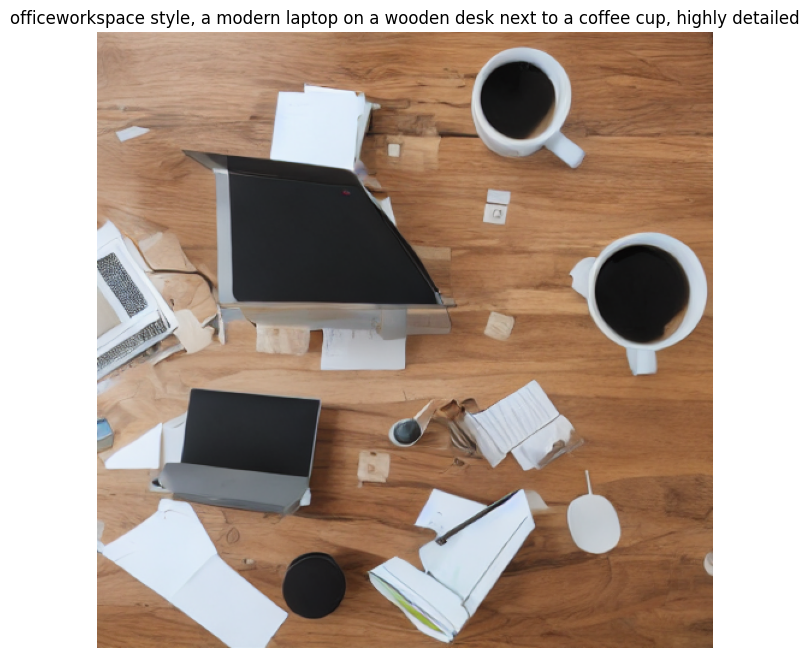

In [7]:
import torch
from diffusers import StableDiffusionPipeline
from peft import PeftModel
import matplotlib.pyplot as plt

# Configuration
model_id = "runwayml/stable-diffusion-v1-5"
lora_weights_path = "/content/officeworkspace-lora/"
prompt = "officeworkspace style, a modern laptop on a wooden desk next to a coffee cup, highly detailed"

# 1. Load the base pipeline
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    safety_checker=None
).to("cuda")

# 2. Load the LoRA weights specifically as a PEFT model over the UNet
# This handles the 'adapter_model.safetensors' file correctly
print("Loading LoRA weights...")
pipe.unet = PeftModel.from_pretrained(pipe.unet, lora_weights_path)

# Generate image
print(f"Generating image for prompt: {prompt}")
with torch.inference_mode():
    # Note: When using PeftModel, the pipeline works normally
    image = pipe(prompt, num_inference_steps=30, guidance_scale=7.5).images[0]

# Display the result
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis("off")
plt.title(prompt)
plt.show()